# Preparação dos dados — Chokepoints marítimos do petróleo (EIA)

**Projeto:** O Preço da Guerra 
**Autor:** Luis Miguel Pereira Silva · PG60390 
**Universidade:** Universidade do Minho — Mestrado em IA 
**Disciplina:** SVDC 

---

## Fonte

[U.S. Energy Information Administration — World Oil Transit Chokepoints (Mar 2026)](https://www.eia.gov/international/analysis/special-topics/world-oil-transit-chokepoints) 
Os dados aparecem em tabelas dentro do relatório PDF da EIA — aqui transcrevemo-los manualmente para CSVs limpos.

## Ficheiros produzidos

- `chokepoints_overview.csv` — volume anual (mb/d) por chokepoint, 2020 a 1H2025
- `hormuz_flows.csv` — detalhe do Estreito de Ormuz (crude vs petroleum products)
- `suez_babmandeb_flows.csv` — Suez + SUMED + Bab el-Mandeb
- `cape_good_hope_flows.csv` — Cabo da Boa Esperança (rota alternativa)
- `hormuz_destinations.csv` — para onde vai o petróleo de Ormuz

## Porque transcrição manual?

A EIA disponibiliza os dados como **figuras + tabelas em PDF** — não há API nem CSV. 
Como o universo é pequeno (≈40 valores no total) é mais simples transcrever do que automatizar OCR.
Cada CSV tem uma coluna de validação (`note` ou `description`) com a citação exata da fonte.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')


## 1. Reconstruir `chokepoints_overview.csv`

Tabela 1 do relatório EIA — volume anual em milhões de barris/dia.


In [2]:
overview_data = [
    # chokepoint,                        2020, 2021, 2022, 2023, 2024, 1H2025
    ('Strait of Malacca',                22.8, 22.1, 23.0, 24.0, 22.5, 23.2),
    ('Strait of Hormuz',                 19.2, 19.7, 21.9, 21.8, 20.7, 20.9),
    ('Suez Canal and SUMED Pipeline',     5.4,  5.2,  7.3,  8.8,  4.8,  4.9),
    ('Bab el-Mandeb',                     5.7,  6.0,  8.0,  9.3,  4.1,  4.2),
    ('Danish Straits',                    3.2,  3.4,  3.7,  4.2,  4.6,  4.9),
    ('Turkish Straits',                   3.1,  3.3,  3.5,  3.6,  3.7,  3.7),
    ('Cape of Good Hope',                 4.6,  4.5,  4.8,  6.4,  8.5,  9.1),
    ('Panama Canal',                      2.5,  2.8,  2.6,  2.4,  2.2,  2.3),
]
overview = pd.DataFrame(overview_data, columns=['chokepoint','2020','2021','2022','2023','2024','1H2025'])
overview.to_csv(PROCESSED / 'chokepoints_overview.csv', index=False)
print('✓ chokepoints_overview.csv'); overview


✓ chokepoints_overview.csv


,chokepoint,2020,2021,2022,2023,2024,1H2025
0,Strait of Malacca,22.8,22.1,23.0,24.0,22.5,23.2
1,Strait of Hormuz,19.2,19.7,21.9,21.8,20.7,20.9
2,Suez Canal and SUMED Pipeline,5.4,5.2,7.3,8.8,4.8,4.9
3,Bab el-Mandeb,5.7,6.0,8.0,9.3,4.1,4.2
4,Danish Straits,3.2,3.4,3.7,4.2,4.6,4.9
5,Turkish Straits,3.1,3.3,3.5,3.6,3.7,3.7
6,Cape of Good Hope,4.6,4.5,4.8,6.4,8.5,9.1
7,Panama Canal,2.5,2.8,2.6,2.4,2.2,2.3


## 2. Hormuz — detalhe crude vs products


In [3]:
hormuz_data = [
    ('Crude oil and condensate', 14.6, 15.1, 16.5, 16.9, 16.0, 16.3),
    ('Petroleum products',        4.6,  4.6,  5.4,  4.9,  4.7,  4.6),
]
hormuz = pd.DataFrame(hormuz_data, columns=['type','2020','2021','2022','2023','2024','1H2025'])
hormuz.to_csv(PROCESSED / 'hormuz_flows.csv', index=False)
print('✓ hormuz_flows.csv'); hormuz


✓ hormuz_flows.csv


,type,2020,2021,2022,2023,2024,1H2025
0,Crude oil and condensate,14.6,15.1,16.5,16.9,16.0,16.3
1,Petroleum products,4.6,4.6,5.4,4.9,4.7,4.6


## 3. Suez + Bab el-Mandeb

Note-se a **queda de ~50% em 2024** — efeito dos ataques Houthi (Mar Vermelho).


In [4]:
sbm_data = [
    ('Suez Canal — northbound',     2.5, 2.4, 3.5, 4.4, 2.4, 2.5),
    ('Suez Canal — southbound',     1.7, 1.6, 2.3, 2.9, 1.5, 1.6),
    ('SUMED Pipeline',              1.2, 1.2, 1.5, 1.5, 0.9, 0.8),
    ('Bab el-Mandeb — northbound',  3.0, 3.2, 4.6, 5.4, 2.4, 2.5),
    ('Bab el-Mandeb — southbound',  2.7, 2.8, 3.4, 3.9, 1.7, 1.7),
]
sbm = pd.DataFrame(sbm_data, columns=['route','2020','2021','2022','2023','2024','1H2025'])
sbm.to_csv(PROCESSED / 'suez_babmandeb_flows.csv', index=False)
print('✓ suez_babmandeb_flows.csv'); sbm


✓ suez_babmandeb_flows.csv


,route,2020,2021,2022,2023,2024,1H2025
0,Suez Canal — northbound,2.5,2.4,3.5,4.4,2.4,2.5
1,Suez Canal — southbound,1.7,1.6,2.3,2.9,1.5,1.6
2,SUMED Pipeline,1.2,1.2,1.5,1.5,0.9,0.8
3,Bab el-Mandeb — northbound,3.0,3.2,4.6,5.4,2.4,2.5
4,Bab el-Mandeb — southbound,2.7,2.8,3.4,3.9,1.7,1.7


## 4. Cabo da Boa Esperança

A rota alternativa quando os chokepoints estão bloqueados. **Subiu 100% em 2024** 
porque os armadores começaram a contornar África para evitar o Mar Vermelho.


In [5]:
cape_data = [
    ('Crude oil',           2.6, 2.6, 2.8, 3.7, 4.6, 4.9),
    ('Petroleum products',  2.0, 1.9, 2.0, 2.7, 3.9, 4.2),
]
cape = pd.DataFrame(cape_data, columns=['type','2020','2021','2022','2023','2024','1H2025'])
cape.to_csv(PROCESSED / 'cape_good_hope_flows.csv', index=False)
print('✓ cape_good_hope_flows.csv'); cape


✓ cape_good_hope_flows.csv


,type,2020,2021,2022,2023,2024,1H2025
0,Crude oil,2.6,2.6,2.8,3.7,4.6,4.9
1,Petroleum products,2.0,1.9,2.0,2.7,3.9,4.2


## 5. Destinos do petróleo de Ormuz

Quem é que mais depende deste estrangulamento? **89% vai para a Ásia.**
Aqui usamos % aproximadas (a EIA dá ranges) — o que é coerente com a realidade do mercado spot.


In [6]:
destinations_data = [
    # destination,    region,   share_percent, note
    ('China',          'Ásia',  46, 'Maior comprador isolado — ~46% das exportações de Ormuz'),
    ('Índia',          'Ásia',  18, 'Top 4 + reformulação russa'),
    ('Japão',          'Ásia',   6, 'Top 4 — economia altamente dependente de importação'),
    ('Coreia do Sul',  'Ásia',   4, 'Top 4'),
    ('Outros Ásia',    'Ásia',  15, 'Tailândia, Singapura, Filipinas, Taiwan'),
    ('Europa',         'Europa', 6, 'Itália, Espanha, Holanda — UE em transição energética'),
    ('EUA',            'Américas', 2, 'Inferior pós shale revolution'),
    ('Outros',         'Resto',  3, 'África, Médio Oriente intra-regional'),
]
dest = pd.DataFrame(destinations_data, columns=['destination','region','share_percent','note'])
assert dest.share_percent.sum() == 100, 'Soma deve ser 100'
dest.to_csv(PROCESSED / 'hormuz_destinations.csv', index=False)
print('✓ hormuz_destinations.csv'); dest


✓ hormuz_destinations.csv


,destination,region,share_percent,note
0,China,Ásia,46,Maior comprador isolado — ~46% das exportações...
1,Índia,Ásia,18,Top 4 + reformulação russa
2,Japão,Ásia,6,Top 4 — economia altamente dependente de impor...
3,Coreia do Sul,Ásia,4,Top 4
4,Outros Ásia,Ásia,15,"Tailândia, Singapura, Filipinas, Taiwan"
5,Europa,Europa,6,"Itália, Espanha, Holanda — UE em transição ene..."
6,EUA,Américas,2,Inferior pós shale revolution
7,Outros,Resto,3,"África, Médio Oriente intra-regional"


## 6. Visualização global — todos os chokepoints


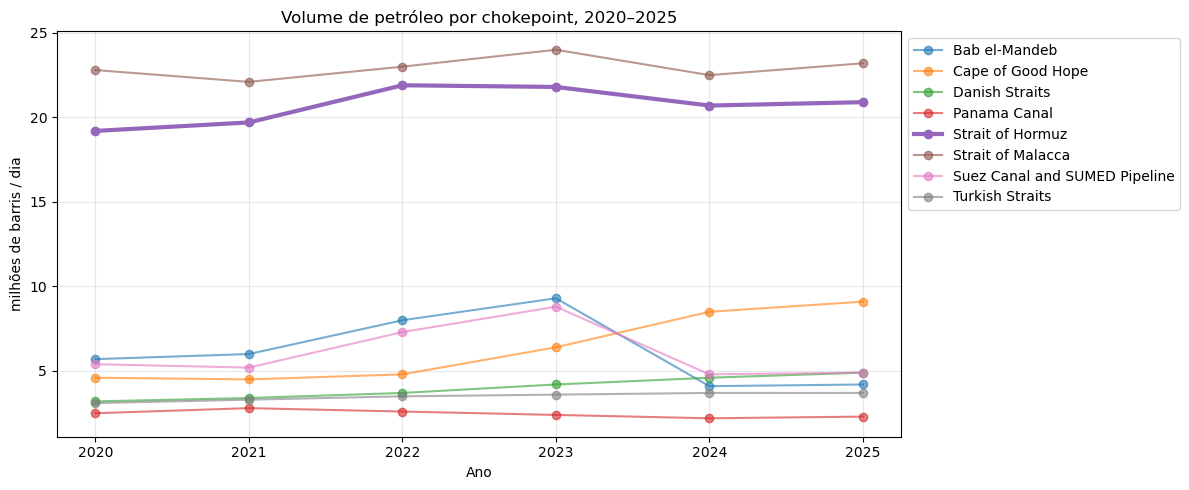

In [7]:
long = overview.melt(id_vars='chokepoint', var_name='ano', value_name='mb_per_dia')
long['ano'] = long['ano'].replace({'1H2025':'2025'})

fig, ax = plt.subplots(figsize=(12, 5))
for cp, g in long.groupby('chokepoint'):
    ax.plot(g.ano, g.mb_per_dia, marker='o', label=cp,
            linewidth=3 if cp == 'Strait of Hormuz' else 1.5,
            alpha=1.0 if cp == 'Strait of Hormuz' else 0.6)
ax.set_ylabel('milhões de barris / dia'); ax.set_xlabel('Ano')
ax.set_title('Volume de petróleo por chokepoint, 2020–2025')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1)); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---

## ✓ Resultado

Cinco CSVs prontos a alimentar:
- **Secção I** (mapa-mundo): valores numéricos do `chokepoints_overview.csv`
- **Secção II** (linhas no tempo): `chokepoints_overview.csv` em formato *long*
- **Secção III** (Sankey de destinos): `hormuz_destinations.csv` com `region` + `share_percent` numéricos
